In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib Inline
%config InlineBackend.figure_format = "svg"
sns.set(rc={'axes.facecolor':'#ebeaf1', 'figure.facecolor':'lightgrey'})

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")
test_id = df_test["Id"]

In [3]:
df_train.drop("Id", axis=1, inplace=True)
df_test.drop("Id", axis=1, inplace=True)

## EDA (Exploratory Data Analysis)

### Target variable and base statistics

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  float64
 1   years_of_experience  10000 non-null  float64
 2   lesson_price         10000 non-null  float64
 3   qualification        10000 non-null  float64
 4   physics              10000 non-null  float64
 5   chemistry            10000 non-null  float64
 6   biology              10000 non-null  float64
 7   english              10000 non-null  float64
 8   geography            10000 non-null  float64
 9   history              10000 non-null  float64
 10  mean_exam_points     10000 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 859.5 KB


* **Id** - unique identifier
* **age** - Age of tutor
* **years_of_experience**
* **lesson_price**
* **qualification**
* **physics** - teaches physics
* **chemistry** - teaches chemistry
* **biology** - teaches biology
* **english** - teaches english
* **geography** - teaches geography
* **history** - teaches history
* **mean_exam_points** - target feature

### EDA (Exploratory data analysis)

### Target variable and base statistic

In [17]:
df_train.describe()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.878000,1.986800,1699.105000,1.719500,0.375000,0.132900,0.109600,0.053700,0.032100,0.019400,63.737300
std,8.043929,1.772213,524.886654,0.792264,0.484147,0.339484,0.312406,0.225436,0.176274,0.137933,14.705574
min,23.000000,0.000000,200.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000
25%,40.000000,0.000000,1300.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,53.000000
50%,46.000000,2.000000,1500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,63.000000
75%,51.000000,3.000000,2150.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.000000
max,68.000000,10.000000,3950.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000


In [18]:
df_train.head()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
0,40.0,0.0,1400.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,61
1,48.0,4.0,2850.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,76
2,39.0,0.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,53
3,46.0,5.0,1400.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,54
4,43.0,1.0,1500.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,57


In [4]:
def reduce_mem_usage(df):
    """
    Iterate through all the columns of a dataframe and modify the data type
    to reduce memory usage
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print("Memory usage of dataframe is {:.2f} MB".format(start_mem))
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                      df[col] = df[col].astype(np.float64)  
        else:
            df[col] = df[col].astype("category")
    end_mem = df.memory_usage().sum() /1024**2
    print("Memory usage after optimization is: {:.2f} MB".format(end_mem))
    print("Decreased by {:.1f}%".format(100 * (start_mem - end_mem) / start_mem))
    return df

In [5]:
df_train = reduce_mem_usage(df_train)

Memory usage of dataframe is 0.84 MB
Memory usage after optimization is: 0.39 MB
Decreased by 53.4%


Take a look on our target feature

In [270]:
def measures_of_the_central_trend(data: pd.Series):
    mean_ = data.mean()
    median_ = data.median()
    mode_ = data.mode()[0]
    return mean_, median_, mode_

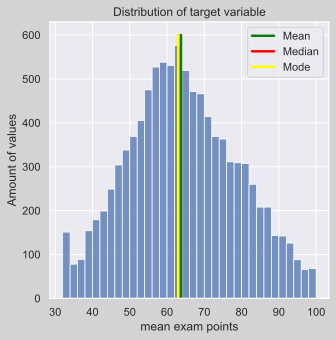

In [271]:
target_mean, target_median, target_mode = measures_of_the_central_trend(df_train["mean_exam_points"])
y = np.linspace(0, 600, 600)

plt.figure(figsize=(5, 5))

sns.histplot(data=df_train, x="mean_exam_points",bins=34)
plt.plot([target_mean] * 600, y, color="green", label="Mean", linewidth=2.5)
plt.plot([target_median] * 600, y, color="red", label="Median", linewidth=2.5)
plt.plot([target_mode] * 600, y, color="yellow", label="Mode", linewidth=2.5)

plt.xlabel("mean exam points")
plt.ylabel("Amount of values")
plt.title("Distribution of target variable")
plt.legend(loc="upper right")

plt.show()

The distribution of target variable appears to be normal. The majority of data concentrated in the middle of the chart. Mean, median and mode are almost at same point.

### Continuous variables

#### Age

In [272]:
age_mean, age_median, age_mode = measures_of_the_central_trend(df_train["age"])
print(f"Measures of the central trend for Age:\nMean - {age_mean}\nMode - {age_mode}\nMedian - {age_median}")

Measures of the central trend for Age:
Mean - 45.87799835205078
Mode - 48.0
Median - 46.0


<Figure size 300x300 with 0 Axes>

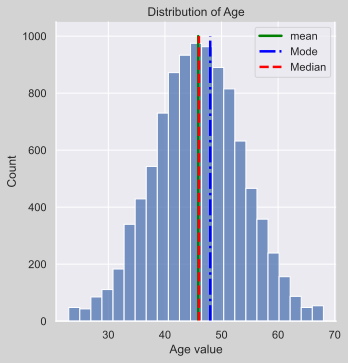

In [273]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1000, 1000)
sns.displot(df_train["age"], bins=23, kde=False)
plt.plot([age_mean] * 1000, y, color="green", linewidth=2.5, label="mean")
plt.plot([age_mode] * 1000, y, color="blue", linewidth=2.5, label="Mode", linestyle="-.")
plt.plot([age_median] * 1000, y, color="red", linewidth=2.5, label="Median", linestyle="dashed")

plt.title("Distribution of Age")
plt.ylabel("Count")
plt.xlabel("Age value")
plt.legend(loc="upper right")

plt.show()

#### Lesson price

In [67]:
lesson_price_mean, lesson_price_median, lesson_price_mode = measures_of_the_central_trend(df_train["lesson_price"])
print(f"Measures of the central trend for lesson_price:\nMean - {lesson_price_mean}\nMode - {lesson_price_mode}\nMedian - {lesson_price_median}")

Measures of the central trend for lesson_price:
Mean - 1699.10498046875
Mode - 1450.0
Median - 1500.0


<Figure size 300x300 with 0 Axes>

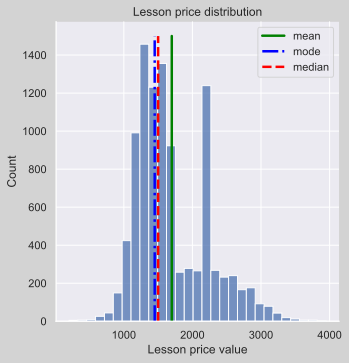

In [307]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1500, 1500)
sns.displot(df_train["lesson_price"], bins=29, kde=False)
plt.plot([lesson_price_mean] * 1500, y, color="green", linewidth=2.5, label="mean")
plt.plot([lesson_price_mode] * 1500, y, color="blue", linewidth=2.5, linestyle="-.", label="mode")
plt.plot([lesson_price_median] * 1500, y, color="red", linewidth=2.5, linestyle="dashed", label="median")

plt.title("Lesson price distribution")
plt.ylabel("Count")
plt.xlabel("Lesson price value")
plt.legend(loc="upper right")

plt.show()

According to the histograms, The Age distribution tends to be normal, measures of the central trand are located quite close to each other. The most common age for this data set is in the region of 48. The data in Lesson price distribution are different. The most popular tutors have lesson price between 1000 and 2000. Mode and median in this feature are located at almost the same point, mean value is a bit shifted beacause the data

The yongest tutor is 23 years old and the oldest is 68. The cheapest lesson price is 200, the most expensive - 3950. Based on chart tutors with this lesson price are quite rare, it can be outliers.

Now we should use box plot in order to give a first sight on outliers and calc quartiles

In [112]:
def calculate_quantiles(data):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    IQR = q3 - q1
    return q1, q3, IQR

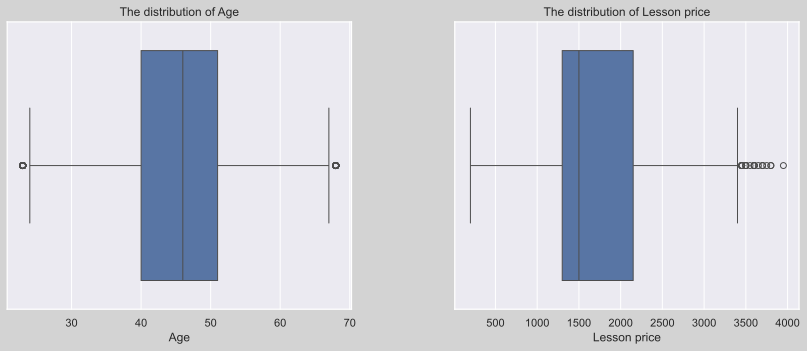

In [106]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5), 
    gridspec_kw={'left': 0, 'right': 1.1, 'top': 1, 'bottom': 0.2}
)

ax1, ax2 = axes.flatten()

sns.boxplot(data=df_train, ax=ax1, x="age")
ax1.set_xlabel("Age")
ax1.set_title("The distribution of Age")

sns.boxplot(data=df_train, ax=ax2, x="lesson_price")
ax2.set_xlabel("Lesson price")
ax2.set_title("The distribution of Lesson price")

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

In [118]:
age_q1, age_q3, age_iqr = calculate_quantiles(df_train["age"])
lp_q1, lp_q3, lp_iqr = calculate_quantiles(df_train["lesson_price"])

print(f"Age Q1 - {age_q1}, Q3 - {age_q3}, IQR - {age_iqr}")
print(f"Lesson Price Q1 - {lp_q1}, Q3 - {lp_q3}, IQR - {lp_iqr}\n")

age_low_limit = age_q1 - age_iqr * 1.5
age_high_limit = age_q3 + age_iqr * 1.5

lp_low_limit = lp_q1 - lp_iqr * 1.5
lp_high_limit = lp_q3 + lp_iqr * 1.5

print(f"Low limit for the Age feature is {age_low_limit} High limit - {age_high_limit}")
print(f"Low limit for the Lesson price feature is {lp_low_limit} High limit - {lp_high_limit}")

Age Q1 - 40.0, Q3 - 51.0, IQR - 11.0
Lesson Price Q1 - 1300.0, Q3 - 2150.0, IQR - 850.0

Low limit for the Age feature is 23.5 High limit - 67.5
Low limit for the Lesson price feature is 25.0 High limit - 3425.0


#### Years of experience

<Figure size 300x300 with 0 Axes>

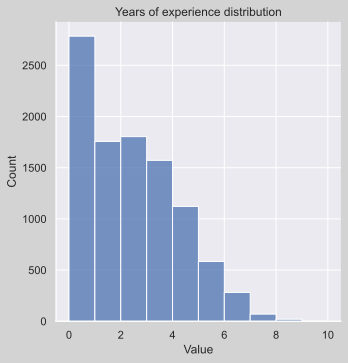

In [306]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1500, 1500)
sns.displot(df_train["years_of_experience"], bins=10, kde=False)

plt.title("Years of experience distribution")
plt.ylabel("Count")
plt.xlabel("Value")

plt.show()

The majority of tutors do not have experience. 
The biggest number of tuturs within all teachers is the tutors who do not have experience. The years of experience distribution appears to be the step with plato since 1 to 3 years. According this chart tutors with 7 and more years of experience are the rarest.

### Categorical variables

In [129]:
category = ["physics", "chemistry", "biology", "english", "geography", "history"]

In [148]:
df_category = df_train[category]

count_category = df_category.apply(lambda x: sum([i for i in x]), axis=0)
count_category["no_one_category"] = df_category.apply(lambda x: sum([1 if i == 0 else 0 for i in x]) == 6, axis=1).sum()

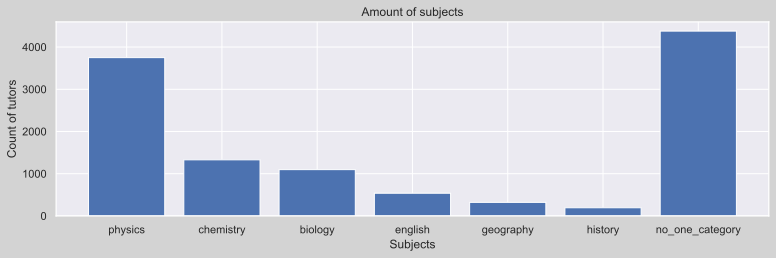

In [305]:
fig, ax = plt.subplots(figsize=(9, 3))

fig.subplots_adjust(left=0, right=1.1, top=1, bottom=0.1)

ax.bar(count_category.index, count_category)
ax.set_xlabel("Subjects")
ax.set_ylabel("Count of tutors")
ax.set_title("Amount of subjects")

plt.show()

The most popular subject is physics - above 3500, unpopular is history - less 500. Chemistry and biology are located almost at the same level - 1200. But the biggest number tutors is tutors who do not have subjects (more than 4300)

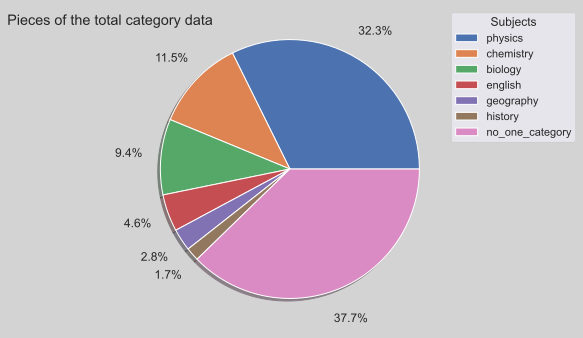

In [236]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

fig.suptitle("Pieces of the total category data")
fig.subplots_adjust(left=0, right=2, top=1, bottom=0.1)

axes.pie(
    x=count_category,
    autopct="%1.1f%%",
    pctdistance=1.25,
    labeldistance=.5,
    shadow=True
)
axes.legend(
    title="Subjects",
    labels=count_category.index,
    bbox_to_anchor=(0.9, 0, 0.5, 1),
)

plt.show()

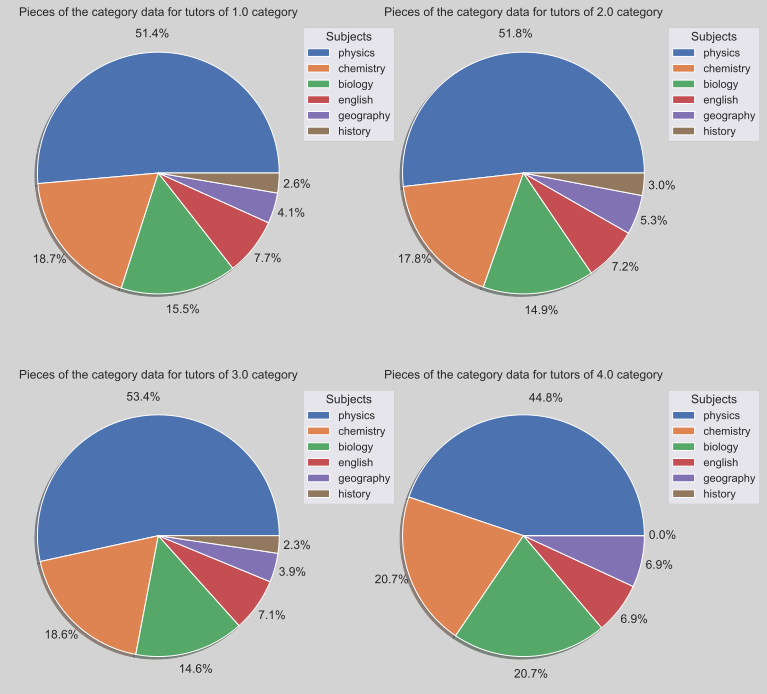

In [262]:
category_grouped = df_train.groupby(by="qualification").agg(
    physics_count = ("physics", "sum"),
    chemistry_count = ("chemistry", "sum"),
    biology_count = ("biology", "sum"),
    english_count = ("english", "sum"),
    geography_count = ("geography", "sum"),
    history_count = ("history", "sum")
)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

ax1, ax2, ax3, ax4 = axes.flatten()

for idx, row in category_grouped.iterrows():
    ax = axes[int(idx - 1) // 2, int(idx - 1) % 2]

    labels = [label.replace("_count", "") for label in row.index]
    
    ax.pie(
        x=row,
        autopct="%1.1f%%",
        pctdistance=1.15,
        labeldistance=.5,
        shadow=True
    )
    ax.legend(
        title="Subjects",
        labels=labels,
        bbox_to_anchor=(0.8, 0.2, 0.5, 0.8),
    )
    
    ax.set_title(f"Pieces of the category data for tutors of {idx} category")


The amount of tutors who teach particular subject in all qualifications stays almost at the same level. The only one qualification wich showed the difference is 4. There is no tutors who teach history and amount of tutors who teach physics is less than in the different qualifications. These two factors allowed the rest subjects to be increased

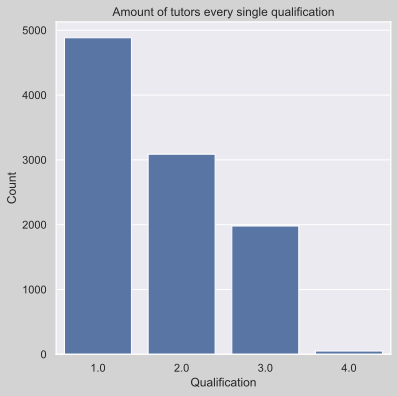

In [309]:
plt.figure(figsize=(6, 6))

sns.countplot(
    data=df_train,
    x="qualification"
)

plt.xlabel("Qualification")
plt.ylabel("Count")
plt.title("Amount of tutors every single qualification")

plt.show()

Majority of tutors is tutors of 1 qualification. Forth qualification appears to be the rarest, it can be connected with the difficulty of getting this qualification

### Interaction with the target variable and each other

In [319]:
def show_subject_tutor_distribution_by_experience_and_qualification(df, subjects, qualification):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(11, 8))
    fig.suptitle(f"Tutors of {qualification} qualification who teach subjects by years of experience")
    
    for idx, subject in enumerate(subjects):
        ax = axes[idx // 3, idx % 3]
        
        subject_df = df[(df["qualification"] == qualification) & (df[subject] == 1)]
        
        all_years = sorted(subject_df["years_of_experience"].unique())
        
        years = []
        scores = []
        
        for year in all_years:
            data = subject_df[(subject_df["years_of_experience"] == year)]
            if not data.empty:
                years.append(year)
                scores.append(data["mean_exam_points"].mean())
        
        x = np.arange(len(all_years))
        width = 0.35
        
        ax.bar(x, scores, width, alpha=0.7)
        
        ax.set_xlabel("Years of experience")
        ax.set_ylabel("Mean exam points")
        ax.set_title(f"{subject}")
        
    plt.tight_layout()
    plt.show()

<Figure size 200x200 with 0 Axes>

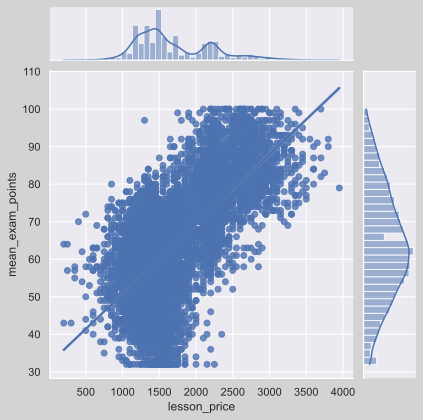

In [273]:
plt.figure(figsize=(2, 2))

sns.jointplot(data=df_train, x="lesson_price", y="mean_exam_points", kind="reg")

plt.show()

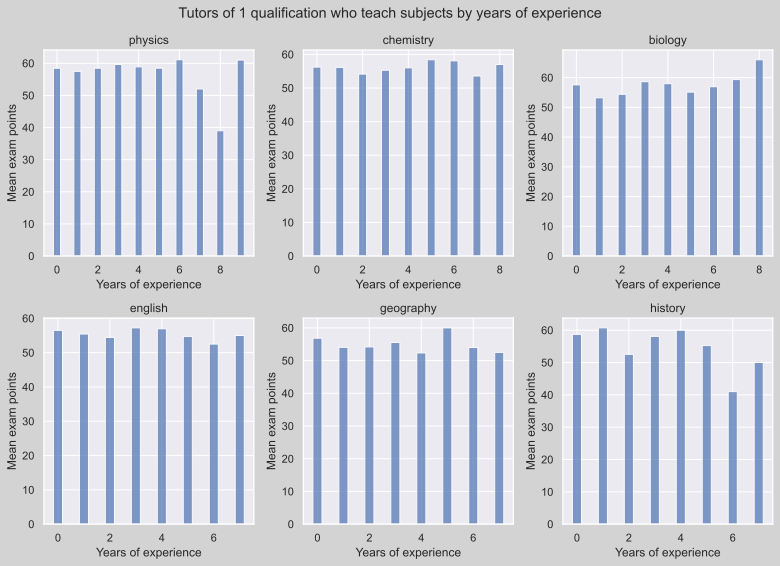

In [320]:
show_subject_tutor_distribution_by_experience_and_qualification(df_train, category, 1)

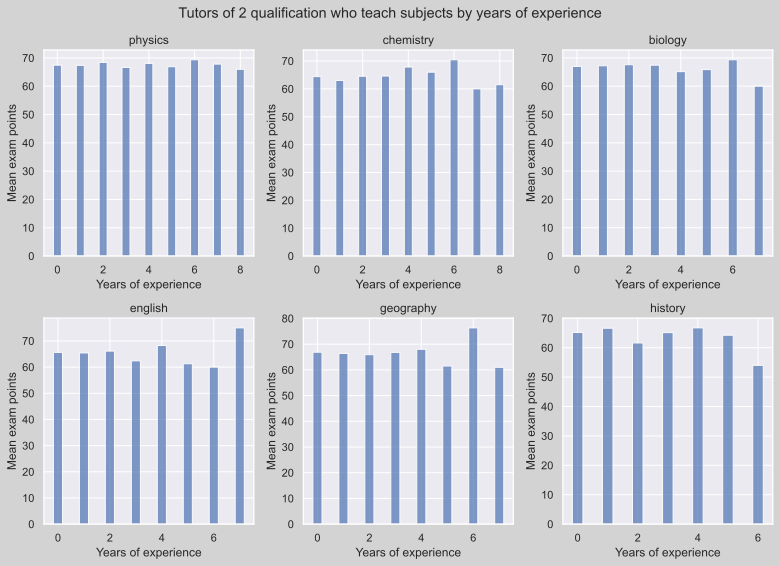

In [321]:
show_subject_tutor_distribution_by_experience_and_qualification(df_train, category, 2)

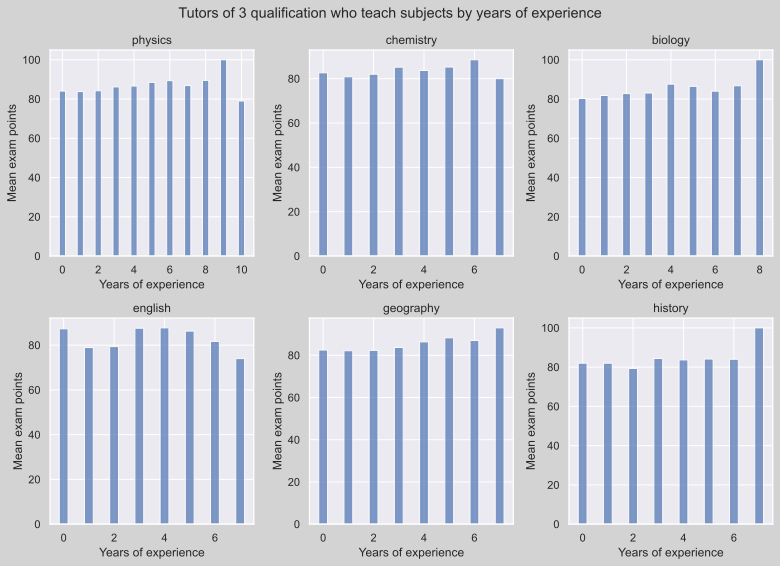

In [322]:
show_subject_tutor_distribution_by_experience_and_qualification(df_train, category, 3)

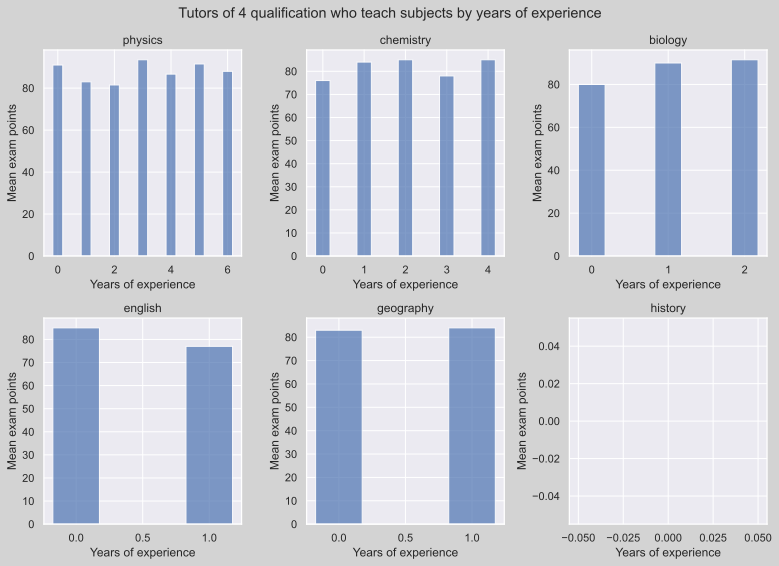

In [323]:
show_subject_tutor_distribution_by_experience_and_qualification(df_train, category, 4)

The upward trend can be seen between lesson price and mean exam points. As the lesson price grows, the mean exam points increases too.

As Regards mean exam points in different qualifications groups, we can make next outcomes:
- The maximum exam points in average for tutors of 1 qualification in spite of experience is a bit more than 60. The biggest variance in the average exam scores within all years of experience turned out to be in History subject
- Scores in 2 qualification a bit higher but still quite low. Despite this fact, tutors in this category who teach geography and have 6 years of experience managed to reach of 80 points in average.
- The difference in preparation to exam between third qualification and previous displayed on the average exam points. The minimus exam points in average for tutor of 3 qualification is 80.
- The numbor of tutors of 4 qualification is quite small. Nevertheless, the average exam points in this qualification do not surpass scores of 3 qualification.

Still there is not clear upward trend in years of experience. A lot of experience is not an indicator of high scores. There is no linear connection between years of experience and mean exam points

<Figure size 400x400 with 0 Axes>

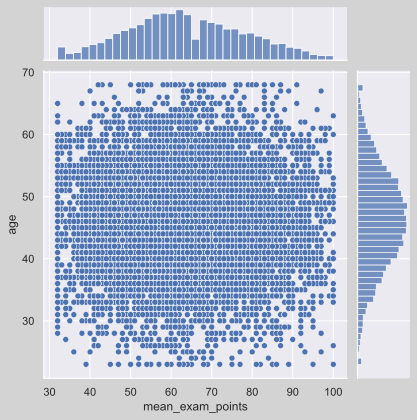

In [325]:
plt.figure(figsize=(4, 4))

sns.jointplot(data=df_train, x="mean_exam_points", y="age")

plt.show()

Accorring the chart above, there is no big difference for tutor age. The Student with young tutor can reach high score as well as old. At least there is no the lenear connection, but maybe should try make combination using different features

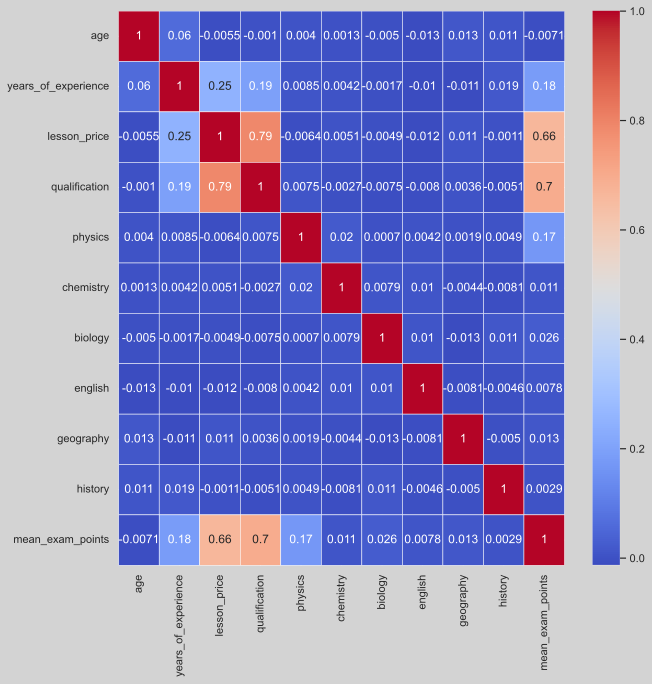

In [329]:
plt.figure(figsize=(10, 10))

corr_matrix = np.round(df_train.corr(), 4)

sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)

plt.show()

The Heat map chart proved outcomes made before:
- There is big correlation between mean exam point and qualification (0.7), mean exam point and lesson price (0.66), qualification and lesson price (0.79).
- There is no the linear connetion between age and mean exam point, year of experience and mean exam point. But should try the combination of these features. 

## BaseLine model (Decision Tree)

In [6]:
class Node:

    def __init__(self, t, idx, true_branch, false_branch):
        self.t = t
        self.idx = idx
        self.true_branch = true_branch
        self.false_branch = false_branch

class Leaf:

    def __init__(self, targets):
        self.targets = targets
        self.prediction = self.make_prediction()

    def make_prediction(self):
        prediction = self.targets.mean()
        return prediction


class DecisionTree:
    def __init__(self, n_features, total_samples, max_depth=10, min_sample_leaf=5, random_seed=None):
        self.max_depth = max_depth
        self.min_sample_leaf = min_sample_leaf
        self.total_samples = total_samples
        self.feature_importances_ = np.zeros(n_features)
        self.rng = np.random.RandomState(random_seed)

    def mse(self, targets):
        if len(targets) == 0: return 0
        return np.mean((targets - np.mean(targets))**2)

    def gain(self, left_labels, right_labels, root_mse):
        p = float(left_labels.shape[0]) / (left_labels.shape[0] + right_labels.shape[0])
        return root_mse - p * self.mse(left_labels) - (1 - p) * self.mse(right_labels)

    def split(self, data, labels, column_index, t):        
        left = np.where(data[:, column_index] <= t)
        right = np.where(data[:, column_index] > t)

        true_data = data[left]
        false_data = data[right]
        
        true_labels = labels[left]
        false_labels = labels[right]
        
        return true_data, false_data, true_labels, false_labels

    def get_feature_indices(self, n_features):
        return list(range(n_features))

    def find_best_split(self, data, targets):
        root_mse = self.mse(targets=targets)
        best_gain, best_t, best_index = 0, None, None
        
        feature_indices = self.get_feature_indices(n_features=data.shape[1])

        for idx in feature_indices:
            t_values = np.unique(data[:, idx])
            for t in t_values:
                true_data, false_data, true_targets, false_targets = self.split(data=data, labels=targets, column_index=idx, t=t)
                
                if len(true_data) < self.min_sample_leaf or len(false_data) < self.min_sample_leaf:
                    continue
                
                current_gain = self.gain(left_labels=true_targets, right_labels=false_targets, root_mse=root_mse)
                if current_gain > best_gain:
                    best_gain, best_t, best_index = current_gain, t, idx
                    
        return best_gain, best_t, best_index

    def build_tree(self, data, targets, current_depth=0):
        if current_depth >= self.max_depth:
            return Leaf(targets)
        
        gain, t, idx = self.find_best_split(data=data, targets=targets)
        if gain == 0:
            return Leaf(targets)

        self.feature_importances_[idx] += gain * (len(targets) / self.total_samples)
        
        true_data, false_data, true_targets, false_targets = self.split(data=data, labels=targets, column_index=idx, t=t)
        true_branch = self.build_tree(data=true_data, targets=true_targets, current_depth=current_depth + 1)
        false_branch = self.build_tree(data=false_data, targets=false_targets, current_depth=current_depth + 1)

        return Node(t, idx, true_branch, false_branch)

    def predict_object(self, obj, node):
        if isinstance(node, Leaf):
            return node.prediction
        if obj[node.idx] <= node.t:
            return self.predict_object(obj=obj, node=node.true_branch)
        return self.predict_object(obj=obj, node=node.false_branch)

    def predict(self, data, tree):
        return np.array([self.predict_object(obj=obj, node=tree) for obj in data])

## BaseLine model (Random Forest)

In [7]:
class RandomForest(DecisionTree):
    def __init__(self, n_features, total_samples, max_depth=10, min_sample_leaf=5, random_seed=None):
        super().__init__(n_features, total_samples, max_depth, min_sample_leaf, random_seed)

    def get_feature_indices(self, n_features):
        n_subsample = int(n_features / 3)
        return self.rng.choice(range(n_features), size=n_subsample, replace=False)

    def get_bootstrap(self, data, targets):
        n_samples = data.shape[0]
        indices = self.rng.randint(0, n_samples, size=n_samples)
        return data[indices], targets[indices]

    def fit_forest(self, data, targets, n_trees):
        forest = []
        self.feature_importances_ = np.zeros(len(self.feature_importances_))
        
        for _ in range(n_trees):
            b_data, b_targets = self.get_bootstrap(data=data, targets=targets)
            tree = self.build_tree(b_data, b_targets)
            forest.append(tree)
        return forest

    def tree_vote(self, forest, data):
        all_predicts = np.array([self.predict(data, tree) for tree in forest])
        return np.mean(all_predicts, axis=0)

#### Evaluator

In [8]:
class Evaluator:

    def start_evaluation(self, y, y_pred):
        mse = self.calculate_mse(y, y_pred)
        mae = self.calculate_mae(y, y_pred)
        rmse = self.calculate_rmse(mse)
        r2 = self.calculate_r2(y, y_pred)

        return {
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        }

    def calculate_mse(self, y, y_pred):
        mse = np.mean((y - y_pred)**2)
        return mse

    def calculate_mae(self, y, y_pred):
        mae = np.mean(np.abs(y - y_pred))
        return mae

    def calculate_rmse(self, mse):
        rmse = np.sqrt(mse)
        return rmse

    def calculate_r2(self, y, y_pred):
        r2 = 1 - np.mean((y - y_pred)**2) /np.mean((y - np.mean(y))**2)
        return r2

In [9]:
def train_test_split(X, y, random_seed, use_valid=True):
    
    rng = np.random.RandomState(random_seed)
    all_idx = np.arange(y.shape[0])
    rng.shuffle(all_idx)

    if use_valid:
        train_limit = int(np.round(all_idx.shape[0] * 0.6))
        valid_limit = int(np.round(all_idx.shape[0] * 0.8))
    
        train_idx = all_idx[:train_limit]
        valid_idx = all_idx[train_limit:valid_limit]
        test_idx = all_idx[valid_limit:]
    
        X_train, y_train = X.iloc[train_idx], y[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y[valid_idx]
        X_test, y_test = X.iloc[test_idx], y[test_idx]
        return X_train, X_valid, X_test, y_train, y_valid, y_test
    else:
        train_limit = int(np.round(all_idx.shape[0] * 0.8))
        train_idx = all_idx[:train_limit]
        test_idx = all_idx[train_limit:]
        X_train, y_train = X.iloc[train_idx], y[train_idx]
        X_test, y_test = X.iloc[test_idx], y[test_idx]
        return X_train, X_test, y_train, y_test

In [10]:
class Pipeline:

    def __init__(self):
        self.model = None
        self.my_tree = None
        self.my_forest = None

    def fit_forest(self, X, y, max_depth=10, min_sample_leaf=5, n_trees=3, random_seed=None):
        self.model = RandomForest(
            n_features=X.shape[1], 
            total_samples=X.shape[0], 
            max_depth=max_depth, 
            min_sample_leaf=min_sample_leaf, 
            random_seed=random_seed
        )
        self.my_forest = self.model.fit_forest(data=X.copy().values, targets=y.copy().values, n_trees=n_trees)

        return self

    def predict_forest(self, data):
        predictions = self.model.tree_vote(forest=self.my_forest, data=data)

        return predictions

    def fit(self, X, y, max_depth=10, min_sample_leaf=5):
        self.model = DecisionTree(
            n_features=X.shape[1], 
            total_samples=X.shape[0], 
            max_depth=max_depth, 
            min_sample_leaf=min_sample_leaf
        )
        self.my_tree = self.model.build_tree(data=X.copy().values, targets=y.copy().values)

        return self

    def predict(self, data):
        predictions = self.model.predict(tree=self.my_tree, data=data)

        return predictions

    def prepare_data(self, X, modify_features=None, delete_features=None):
        new_data = X.copy()
        if modify_features:
            new_data = self.create_features(new_data, modify_features)
        if delete_features:
            new_data = self.delete_feature(new_data, delete_features)
        return new_data

    def create_features(self, X, new_features):
        
        for feature in new_features:
            new_feature_info_list = new_features[feature]

            if feature == "modifying":
                for feature_info in new_feature_info_list:
                    X.loc[X[feature_info[0]] == feature_info[1], feature_info[0]] = feature_info[2]
            if feature == "divide":
                for feature_info in new_feature_info_list:
                    X[feature_info[0]] = X[feature_info[1]] / X[feature_info[2]]
            if feature == "bool":
                for feature_info in new_feature_info_list:
                    X[feature_info[0]] = (X[feature_info[1]] > feature_info[2]).astype(int)
            if feature == "effective_index":
                for feature_info in new_feature_info_list:
                    X[feature_info[0]] = (X[feature_info[1]] * (X[feature_info[2]] + 1)) / X[feature_info[3]]
            if feature == "deviation":
                for feature_info in new_feature_info_list:
                    X[feature_info[0]] = X[feature_info[2]] - X.groupby(feature_info[1])[feature_info[2]].transform("mean")
            if feature == "binning":
                for feature_info in new_feature_info_list:
                    bins = feature_info[2]["bins"]
                    labels = feature_info[2]["labels"]
                    X[feature_info[0]] = pd.cut(
                        X[feature_info[1]],
                        bins=bins,
                        labels=labels,
                        right=False
                    ).astype(int)
            if feature == "multiply":
                for feature_info in new_feature_info_list:
                    X[feature_info[0]] = X[feature_info[1]] * X[feature_info[2]]

        return X

    def delete_feature(self, X, delete_features):

        X.drop(delete_features, axis=1, inplace=True)

        return X

#### Baseline model fit

In [490]:
X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]

X_train, X_valid, X_test, y_train, y_valid, y_test = train_test_split(X=X, y=y, random_seed=42)
pl = Pipeline()
pl.fit(X_train, y_train)

train_predictions = pl.predict(data=X_train.values)
valid_predictions = pl.predict(data=X_valid.values)
evaluator = Evaluator()
train_metrix = evaluator.start_evaluation(y=y_train, y_pred=train_predictions)
print("-"*100)
valid_metrix = evaluator.start_evaluation(y=y_valid, y_pred=valid_predictions)

MAE: 6.325190450338773
MSE: 62.70894029845311
RMSE: 7.918897669401538
R2: 0.7148470523070227
----------------------------------------------------------------------------------------------------
MAE: 7.186375178013857
MSE: 82.38018927132848
RMSE: 9.076353302473878
R2: 0.6056167637924148


After fitting we have got next metrics: The mean typical error is 7.18, $R^2$ is 0.605 it means 60% of the variation in the dependent variable can be explained by the independent variable(s). The remaining 40% of variation is due to other factors not captured by the model or random noise.

### Feature engineering

In [215]:
feature_importance = pd.DataFrame(
    {
        "feature_name": df_train.columns[:-1], "feature_importance": pl.model.feature_importances_
    },
    columns=["feature_name", "feature_importance"]
)
feature_importance

,feature_name,feature_importance
0,age,5.288433
1,years_of_experience,7.692940
2,lesson_price,115.684710
3,qualification,19.980385
4,physics,6.879634
5,chemistry,0.619798
6,biology,0.632738
7,english,0.247021
8,geography,0.139513
9,history,0.039241


5 most valueable features:
- age 5.2
- years_of_experience 7.6
- lesson_price 115.6
- qualification 19.9
- physics 6.8

Almost all of them are not subjects and the most valuable is lesson_price. It does make sense

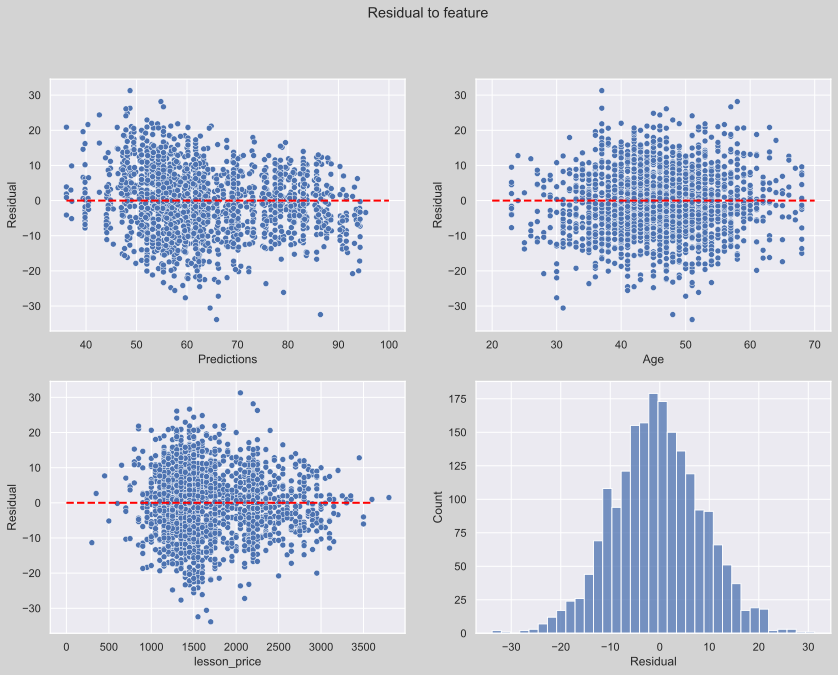

<Figure size 1000x500 with 0 Axes>

In [285]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

plt.figure(figsize=(10, 5))

residual = y_valid - np.round(valid_predictions, 3)

fig.suptitle("Residual to feature")

sns.scatterplot(ax=axes[0,0], x=np.round(valid_predictions, 3), y=residual)
axes[0,0].plot(np.linspace(min(valid_predictions), 100, 100), [0] * 100, color="red", linestyle="--", linewidth=2)
axes[0,0].set_xlabel("Predictions")
axes[0,0].set_ylabel("Residual")

sns.scatterplot(ax=axes[0,1], x=X_valid["age"], y=residual)
axes[0,1].plot(np.linspace(20, 70, 100), [0] * 100, color="red", linestyle="--", linewidth=2)
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("Residual")

sns.scatterplot(ax=axes[1,0], x=X_valid["lesson_price"], y=residual)
axes[1,0].plot(np.linspace(0, 3600, 100), [0] * 100, color="red", linestyle="--", linewidth=2)
axes[1,0].set_xlabel("lesson_price")
axes[1,0].set_ylabel("Residual")

sns.histplot(ax=axes[1,1], x=residual)
axes[1,1].set_xlabel("Residual")
axes[1,1].set_ylabel("Count")

plt.show()

Residual/Predictions:
- There is a small diagonal trend in the point cloud. The majority values fluctuates between 20 and -20. There are objects with quite big residual, should investigate them, predictions for them are located betqeen 50 and 70.

Distribution Residual:
- The Residual distribution looks like a normal distribution

Residual/Age:
- There is no seen trend in this feature. Noise and an absence of a hidden pattern

Residual/Lesson price:
- The value of residual is getting less during the whole period, beginning from +/- 30 to +/- 5. Predictions for tutors with high lesson price is better than tutors with small and middle price. It can be connected with the amount of tutors and the multicollinearity - the correlation between qualification and lesson price is 0.79


Ideas for new features:
- Lesson price / qualification
- Binning Age
- Bool feature < 2500

In [341]:
big_residual = np.where(np.abs(residual) > 10)[0]
df_investigate = df_train.loc[residual.iloc[big_residual].index]
df_investigate.head()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
9717,50.0,0.0,1400.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,45
270,37.0,0.0,1700.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,52
4570,40.0,3.0,1600.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,55
9116,48.0,1.0,1600.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,57
4207,37.0,0.0,1250.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,36


In [351]:
qualification_groups = df_investigate.groupby(by="qualification")

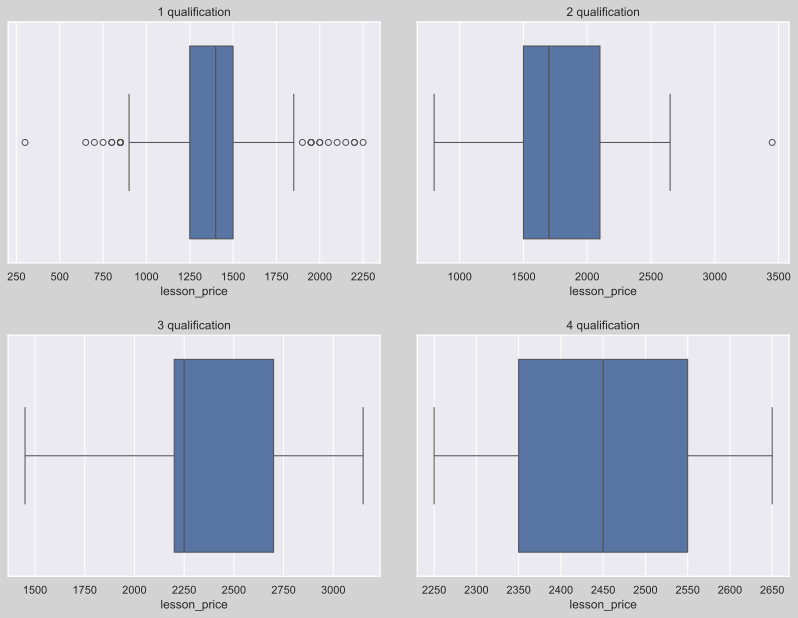

In [401]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.boxplot(ax=axes[0,0], data=qualification_groups.get_group(1.0), x="lesson_price")
axes[0,0].set_title("1 qualification")
sns.boxplot(ax=axes[0,1], data=qualification_groups.get_group(2.0), x="lesson_price")
axes[0,1].set_title("2 qualification")
sns.boxplot(ax=axes[1,0], data=qualification_groups.get_group(3.0), x="lesson_price")
axes[1,0].set_title("3 qualification")
sns.boxplot(ax=axes[1,1], data=qualification_groups.get_group(4.0), x="lesson_price")
axes[1,1].set_title("4 qualification")

plt.subplots_adjust(wspace=0.1, hspace=0.3)

plt.show()

There ara seen limits in the lesson price in all qualifications. The mean lesson price for Tutor of 1 qualification is located between 1250 and 1500. The mean Lesson price of 2 qualification is located between 1500 and 2000. At the same time the mean Lesson price of 3 qualification is between 2250 and 2700. 4 qualification intersects with 3, but the mean a bit more.

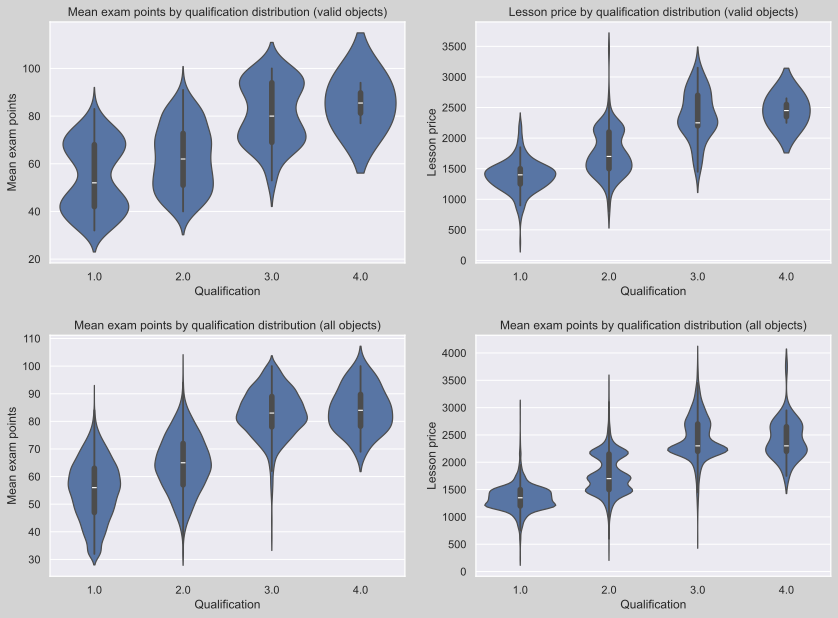

In [400]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.violinplot(ax=axes[0,0], data=df_investigate, x="qualification", y="mean_exam_points")
axes[0,0].set_xlabel("Qualification")
axes[0,0].set_ylabel("Mean exam points")
axes[0,0].set_title("Mean exam points by qualification distribution (valid objects)")

sns.violinplot(ax=axes[0,1], data=df_investigate, x="qualification", y="lesson_price")
axes[0,1].set_xlabel("Qualification")
axes[0,1].set_ylabel("Lesson price")
axes[0,1].set_title("Lesson price by qualification distribution (valid objects)")

sns.violinplot(ax=axes[1,0], data=df_train, x="qualification", y="mean_exam_points")
axes[1,0].set_xlabel("Qualification")
axes[1,0].set_ylabel("Mean exam points")
axes[1,0].set_title("Mean exam points by qualification distribution (all objects)")

sns.violinplot(ax=axes[1,1], data=df_train, x="qualification", y="lesson_price")
axes[1,1].set_xlabel("Qualification")
axes[1,1].set_ylabel("Lesson price")
axes[1,1].set_title("Mean exam points by qualification distribution (all objects)")


plt.subplots_adjust(wspace=0.2, hspace=0.3)

plt.show()

The charts above prove outcomes had made before. The more qualification the more scores and the more lesson price.

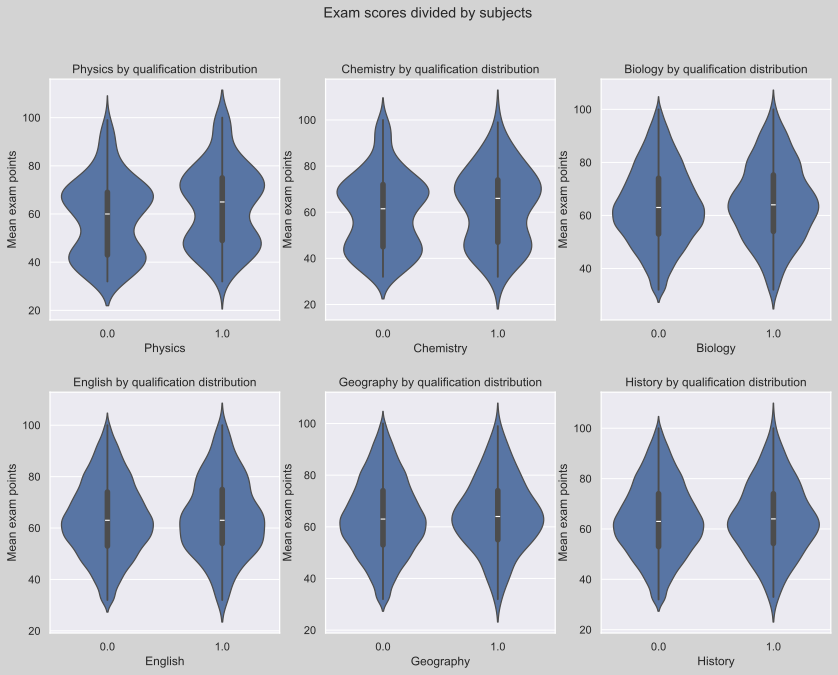

In [424]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 10))

fig.suptitle("Exam scores divided by subjects")

sns.violinplot(ax=axes[0,0], data=df_investigate, x="physics", y="mean_exam_points")
axes[0,0].set_xlabel("Physics")
axes[0,0].set_ylabel("Mean exam points")
axes[0,0].set_title("Physics by qualification distribution")

sns.violinplot(ax=axes[0,1], data=df_investigate, x="chemistry", y="mean_exam_points")
axes[0,1].set_xlabel("Chemistry")
axes[0,1].set_ylabel("Mean exam points")
axes[0,1].set_title("Chemistry by qualification distribution")

sns.violinplot(ax=axes[0,2], data=df_train, x="biology", y="mean_exam_points")
axes[0,2].set_xlabel("Biology")
axes[0,2].set_ylabel("Mean exam points")
axes[0,2].set_title("Biology by qualification distribution")

sns.violinplot(ax=axes[1,0], data=df_train, x="english", y="mean_exam_points")
axes[1,0].set_xlabel("English")
axes[1,0].set_ylabel("Mean exam points")
axes[1,0].set_title("English by qualification distribution")

sns.violinplot(ax=axes[1,1], data=df_train, x="geography", y="mean_exam_points")
axes[1,1].set_xlabel("Geography")
axes[1,1].set_ylabel("Mean exam points")
axes[1,1].set_title("Geography by qualification distribution")

sns.violinplot(ax=axes[1,2], data=df_train, x="history", y="mean_exam_points")
axes[1,2].set_xlabel("History")
axes[1,2].set_ylabel("Mean exam points")
axes[1,2].set_title("History by qualification distribution")


plt.subplots_adjust(wspace=0.2, hspace=0.3)

plt.show()

The charts above remind of a diamond shape. There is no a big difference connected with mean exam points between tutors, who teach subjects and who do not. The median value is located in the region of 60 points.

This bool features (subjects) do not increase growth on their own. 

Ideas for new features:
- Should try to count them or make a combination

In [436]:
df_train_copy = df_train.copy()

df_train_copy["count_subjects"] = df_train[
    ["physics", "chemistry", "biology", "english", "geography", "history"]
    ].apply(lambda x: sum([1 if i == 1 else 0 for i in x]), axis=1)

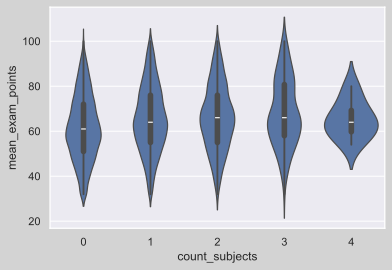

In [437]:
plt.figure(figsize=(6, 4))

sns.violinplot( data=df_train_copy, x="count_subjects", y="mean_exam_points")

plt.show()

And stil there is no big difference in this new feature. The median for different count of subjects is almost at the same point, density for 0, 1, 2, 3 is similar. It is not worth of making this new feature

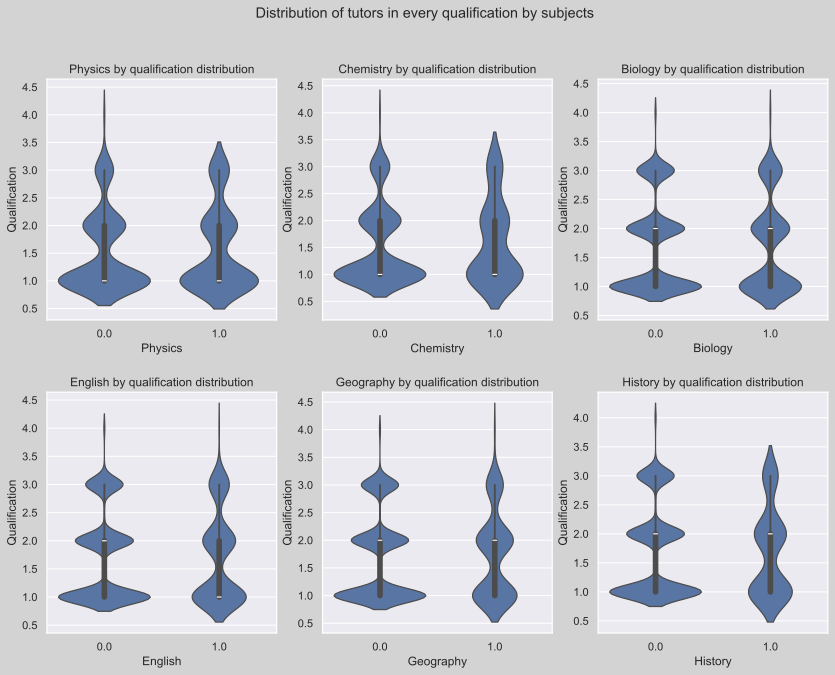

In [425]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 10))

fig.suptitle("Distribution of tutors in every qualification by subjects")

sns.violinplot(ax=axes[0,0], data=df_investigate, x="physics", y="qualification")
axes[0,0].set_xlabel("Physics")
axes[0,0].set_ylabel("Qualification")
axes[0,0].set_title("Physics by qualification distribution")

sns.violinplot(ax=axes[0,1], data=df_investigate, x="chemistry", y="qualification")
axes[0,1].set_xlabel("Chemistry")
axes[0,1].set_ylabel("Qualification")
axes[0,1].set_title("Chemistry by qualification distribution")

sns.violinplot(ax=axes[0,2], data=df_train, x="biology", y="qualification")
axes[0,2].set_xlabel("Biology")
axes[0,2].set_ylabel("Qualification")
axes[0,2].set_title("Biology by qualification distribution")

sns.violinplot(ax=axes[1,0], data=df_train, x="english", y="qualification")
axes[1,0].set_xlabel("English")
axes[1,0].set_ylabel("Qualification")
axes[1,0].set_title("English by qualification distribution")

sns.violinplot(ax=axes[1,1], data=df_train, x="geography", y="qualification")
axes[1,1].set_xlabel("Geography")
axes[1,1].set_ylabel("Qualification")
axes[1,1].set_title("Geography by qualification distribution")

sns.violinplot(ax=axes[1,2], data=df_train, x="history", y="qualification")
axes[1,2].set_xlabel("History")
axes[1,2].set_ylabel("Qualification")
axes[1,2].set_title("History by qualification distribution")


plt.subplots_adjust(wspace=0.2, hspace=0.3)

plt.show()

In average the density of tutors who do not teach the subject is higher than the density of those who do. The biggest density belongs 1 qualification. Tutors of 4 qualification is quite rare and they almost do not teach anything. Tutors of 4 qualification do not teach history and geography at all

The majority of tutors is tutors of 1 qualification. Maybe I should try combine 3 and 4 qualification, cause amount of data, connected with 4 qualification is quite small, and 3 and 4 qualifications appear to be similar

Ideas for new features:
- Combine 3 and 4 qualification

<Figure size 300x300 with 0 Axes>

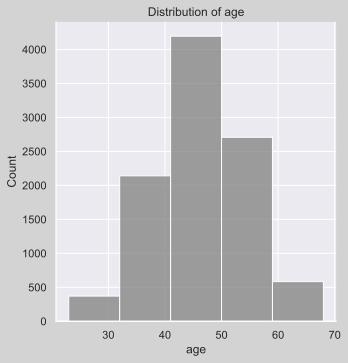

In [631]:
plt.figure(figsize=(3, 3))

sns.displot(df_train["age"], bins=5, color="grey", kde=False, )

plt.title("Distribution of age")
plt.ylabel("Count")
plt.xlabel("age")

plt.show()

### New features

Train metrix:
- MAE: 6.325190450338773
- MSE: 62.70894029845311
- RMSE: 7.918897669401538
- R2: 0.7148470523070227

Valid metrix:
- MAE: 7.186375178013857
- MSE: 82.38018927132848
- RMSE: 9.076353302473878
- R2: 0.6056167637924148

In [28]:
def make_process(
    X_train, X_valid, X_test, 
    y_train, y_valid, y_test,
    modify_features, delete_features, min_sample_leaf=5, 
    max_depth=10, use_test=False, n_tree=5, random_seed=None, fit_forest=False
):
    
    pl = Pipeline()
    X_train_modified = pl.prepare_data(X=X_train, modify_features=modify_features, delete_features=delete_features)
    X_valid_modified = pl.prepare_data(X=X_valid, modify_features=modify_features, delete_features=delete_features)
    if not fit_forest:
        pl.fit(X_train_modified, y_train, min_sample_leaf=min_sample_leaf, max_depth=max_depth)
        
        train_predictions = pl.predict(data=X_train_modified.values)
        valid_predictions = pl.predict(data=X_valid_modified.values)
        
        evaluator = Evaluator()
        train_metrix = evaluator.start_evaluation(y=y_train, y_pred=train_predictions)
        valid_metrix = evaluator.start_evaluation(y=y_valid, y_pred=valid_predictions)
    
        print(f"TRAIN: MAE - {train_metrix["MAE"]}, MSE - {train_metrix["MSE"]}, RMSE - {train_metrix["RMSE"]}, R2 {train_metrix["R2"]}")
        print(f"VALID: MAE - {valid_metrix["MAE"]}, MSE - {valid_metrix["MSE"]}, RMSE - {valid_metrix["RMSE"]}, R2 {valid_metrix["R2"]}")
        
        if use_test:
            X_test_modified = pl.prepare_data(X=X_test, modify_features=modify_features, delete_features=delete_features)
            test_predictions = pl.predict(data=X_test_modified.values)
            test_metrix = evaluator.start_evaluation(y=y_test, y_pred=test_predictions)
            print(f"TEST: MAE - {test_metrix["MAE"]}, MSE - {test_metrix["MSE"]}, RMSE - {test_metrix["RMSE"]}, R2 {test_metrix["R2"]}")
            return X_valid_modified.columns, valid_predictions, test_predictions, pl.model.feature_importances_
        return X_valid_modified.columns, valid_predictions, pl.model.feature_importances_
    else:
        pl.fit_forest(X=X_train_modified, y=y_train, max_depth=max_depth, min_sample_leaf=min_sample_leaf, n_trees=n_tree, random_seed=random_seed)
        
        train_predictions = pl.predict_forest(data=X_train_modified.values)
        valid_predictions = pl.predict_forest(data=X_valid_modified.values)
        
        evaluator = Evaluator()
        train_metrix = evaluator.start_evaluation(y=y_train, y_pred=train_predictions)
        valid_metrix = evaluator.start_evaluation(y=y_valid, y_pred=valid_predictions)
    
        print(f"TRAIN: MAE - {train_metrix["MAE"]}, MSE - {train_metrix["MSE"]}, RMSE - {train_metrix["RMSE"]}, R2 {train_metrix["R2"]}")
        print(f"VALID: MAE - {valid_metrix["MAE"]}, MSE - {valid_metrix["MSE"]}, RMSE - {valid_metrix["RMSE"]}, R2 {valid_metrix["R2"]}")
        
        if use_test:
            X_test_modified = pl.prepare_data(X=X_test, modify_features=modify_features, delete_features=delete_features)
            test_predictions = pl.predict_forest(data=X_test_modified.values)
            test_metrix = evaluator.start_evaluation(y=y_test, y_pred=test_predictions)
            print(f"TEST: MAE - {test_metrix["MAE"]}, MSE - {test_metrix["MSE"]}, RMSE - {test_metrix["RMSE"]}, R2 {test_metrix["R2"]}")
            return X_valid_modified.columns, valid_predictions, test_predictions, pl.model.feature_importances_
        return X_valid_modified.columns, valid_predictions, pl.model.feature_importances_

In [47]:
X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]

X_train, X_valid, X_test, y_train, y_valid, y_test = train_test_split(X=X, y=y, random_seed=42)

modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
    # "deviation": [["price_deviation", "qualification", "lesson_price"]],
    # "multiply": [["price_mul_qual", "lesson_price", "qualification"]],
    "binning": [["age_groups", "age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}]]
}
delete_features = ["lesson_price", "years_of_experience"]

model_columns, valid_predictions, feature_importances_ = make_process(
    X_train, X_valid, X_test, y_train, y_valid, y_test, modify_features=modify_features, delete_features=delete_features
)

TRAIN: MAE - 6.458580828932594, MSE - 65.64787992350792, RMSE - 8.10233792948109, R2 0.7014829722701488
VALID: MAE - 7.062204169365097, MSE - 77.90891964466091, RMSE - 8.826602950436873, R2 0.6270223201636669


In [169]:
feature_importance = pd.DataFrame(
    {
        "feature_name": model_columns, "feature_importance": feature_importances_
    },
    columns=["feature_name", "feature_importance"]
)
feature_importance

,feature_name,feature_importance
0,age,0.835491
1,qualification,111.962873
2,physics,6.732341
3,chemistry,0.235013
4,biology,0.550604
5,english,0.059279
6,geography,0.120303
7,history,0.060303
8,price_per_qual,16.763119
9,experience_qval_price,14.349780


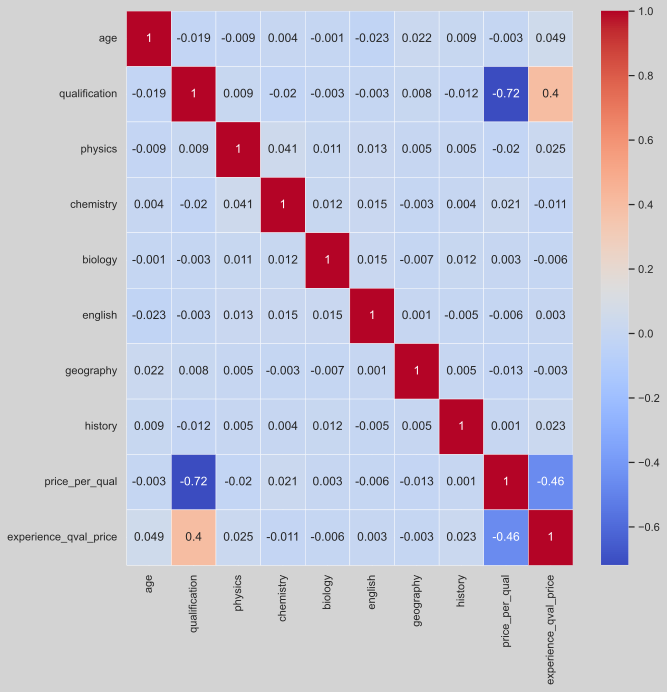

In [156]:
plt.figure(figsize=(10, 10))

corr_matrix = np.round(X_train_modified.corr(), 3)
sns.heatmap(data=corr_matrix, annot=True, linewidths=0.4, cmap="coolwarm")

plt.show()

### Hyperparameters selection

In [12]:
def select_hyperparameters(X, y, modify_features, delete_features):
    best_params = {}
    best_r2_valid = 0
    max_depth_list = [8, 10, 7, 9]
    min_sample_leaf_list = [10, 15, 5, 20]


    X_train, X_valid, X_test, y_train, y_valid, y_test = train_test_split(X=X, y=y, random_seed=42)
    pl = Pipeline()
    X_train_modified = pl.prepare_data(X=X_train, modify_features=modify_features, delete_features=delete_features)
    X_valid_modified = pl.prepare_data(X=X_valid, modify_features=modify_features, delete_features=delete_features)

    for depth in max_depth_list:
        for leaf in min_sample_leaf_list:
            
            pl.fit(X_train_modified, y_train, max_depth=depth, min_sample_leaf=leaf)
    
            train_predictions = pl.predict(data=X_train_modified.values)
            valid_predictions = pl.predict(data=X_valid_modified.values)
    
            evaluator = Evaluator()
            train_metrix = evaluator.start_evaluation(y=y_train, y_pred=train_predictions)
            valid_metrix = evaluator.start_evaluation(y=y_valid, y_pred=valid_predictions)

            if valid_metrix["R2"] > best_r2_valid:
                best_r2_valid = valid_metrix["R2"]
                best_params["R2_valid"] = valid_metrix["R2"]
                best_params["R2_train"] = train_metrix["R2"]
                best_params["depth"] = depth
                best_params["leaf"] = leaf

    return best_params

In [49]:
X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]
modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
    # "deviation": [["price_deviation", "qualification", "lesson_price"]],
    "binning": [["age_groups", "age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}]]
}
delete_features = ["lesson_price", "years_of_experience"]

best_params = select_hyperparameters(X=X, y=y, modify_features=modify_features, delete_features=delete_features)

In [50]:
best_params

{'R2_valid': np.float64(0.6491894684073556),
 'R2_train': np.float64(0.6616709230384277),
 'depth': 7,
 'leaf': 20}

In [51]:
X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]

X_train, X_valid, X_test, y_train, y_valid, y_test = train_test_split(X=X, y=y, random_seed=42)

modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
    "binning": [["age_groups", "age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}]]
}
delete_features = ["lesson_price", "years_of_experience"]

model_columns, valid_predictions, test_predictions, feature_importances_ = make_process(
    X_train, X_valid, X_test, y_train, y_valid, y_test, modify_features=modify_features,
    delete_features=delete_features, use_test=True, max_depth=7, min_sample_leaf=20
)

TRAIN: MAE - 6.915297756955253, MSE - 74.40308108355035, RMSE - 8.625722061575503, R2 0.6616709230384277
VALID: MAE - 6.866205231634904, MSE - 73.27856596766162, RMSE - 8.560290063290006, R2 0.6491894684073556
TEST: MAE - 7.039654348125554, MSE - 75.47776481047788, RMSE - 8.68779401289406, R2 0.6443856552035842


In [179]:
feature_importance = pd.DataFrame(
    {
        "feature_name": model_columns, "feature_importance": feature_importances_
    },
    columns=["feature_name", "feature_importance"]
)
feature_importance

,feature_name,feature_importance
0,age,0.282070
1,qualification,111.962873
2,physics,6.732341
3,chemistry,0.104280
4,biology,0.312074
5,english,0.059279
6,geography,0.000000
7,history,0.060303
8,price_per_qual,15.714070
9,experience_qval_price,12.280926


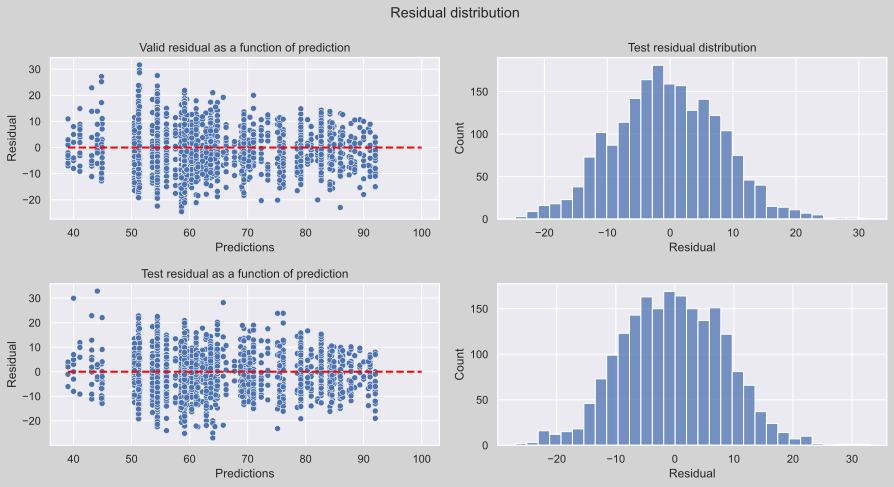

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 7))

valid_residual = y_valid - np.round(valid_predictions, 3)
test_residual = y_test - np.round(test_predictions, 3)

fig.suptitle("Residual distribution")

sns.scatterplot(ax=axes[0,0], x=np.round(valid_predictions, 3), y=valid_residual)
axes[0,0].plot(np.linspace(min(valid_predictions), 100, 100), [0] * 100, color="red", linestyle="--", linewidth=2)
axes[0,0].set_xlabel("Predictions")
axes[0,0].set_ylabel("Residual")
axes[0,0].set_title("Valid residual as a function of prediction")

sns.histplot(ax=axes[0,1], x=valid_residual)
axes[0,1].set_xlabel("Residual")
axes[0,1].set_ylabel("Count")
axes[0,1].set_title("Valid residual distribution")

sns.scatterplot(ax=axes[1,0], x=np.round(test_predictions, 3), y=test_residual)
axes[1,0].plot(np.linspace(min(valid_predictions), 100, 100), [0] * 100, color="red", linestyle="--", linewidth=2)
axes[1,0].set_xlabel("Predictions")
axes[1,0].set_ylabel("Residual")
axes[1,0].set_title("Test residual as a function of prediction")

sns.histplot(ax=axes[1,1], x=test_residual)
axes[1,1].set_xlabel("Residual")
axes[1,1].set_ylabel("Count")
axes[0,1].set_title("Test residual distribution")

plt.subplots_adjust(wspace=0.15, hspace=0.4)

plt.show()

Final outcomes:
- Managed to get rid of diagonal trend in point cloud (valid). Now the model predicts more or less close to zero line.
- Residual distribution is almost normal. Majority of objects concentrated at 0 point. Reduals, wich surpass 20 are quite rare
- The difference in $R^2$ metric between train and valid is 0.012, between valid and test is 0.004, therefore the model is quite stable predciting on new data

### Final predictions using Decision Tree

In [208]:
X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]

modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
    "binning": [["age_groups", "age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}]]
}
delete_features = ["lesson_price", "years_of_experience"]
min_sample_leaf, max_depth= 10, 8

pl = Pipeline()
X_train_modified = pl.prepare_data(X=X, modify_features=modify_features, delete_features=delete_features)
pl.fit(X_train_modified, y, min_sample_leaf=min_sample_leaf, max_depth=max_depth)

X_test_modified = pl.prepare_data(X=df_test, modify_features=modify_features, delete_features=delete_features)

final_prediction = pl.predict(X_test_modified.values)

submission = pd.DataFrame({
    'Id': test_id, 
    'mean_exam_points': final_prediction
})
submission.to_csv('final_submission.csv', index=False)

### Update to Random Forest

In [15]:
X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]

X_train, X_valid, X_test, y_train, y_valid, y_test = train_test_split(X=X, y=y, random_seed=42)

modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
    "binning": [["age_groups", "age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}]]
}
delete_features = ["lesson_price", "years_of_experience"]

pl = Pipeline()
X_train_modified = pl.prepare_data(X=X_train, modify_features=modify_features, delete_features=delete_features)
X_valid_modified = pl.prepare_data(X=X_valid, modify_features=modify_features, delete_features=delete_features)
pl.fit_forest(X=X_train_modified, y=y_train, max_depth=8, min_sample_leaf=10, n_trees=10, random_seed=42)

train_predictions = pl.predict_forest(data=X_train_modified.values)
valid_predictions = pl.predict_forest(data=X_valid_modified.values)

evaluator = Evaluator()
train_metrix = evaluator.start_evaluation(y=y_train, y_pred=train_predictions)
valid_metrix = evaluator.start_evaluation(y=y_valid, y_pred=valid_predictions)

print(f"TRAIN: MAE - {train_metrix["MAE"]}, MSE - {train_metrix["MSE"]}, RMSE - {train_metrix["RMSE"]}, R2 {train_metrix["R2"]}")
print(f"VALID: MAE - {valid_metrix["MAE"]}, MSE - {valid_metrix["MSE"]}, RMSE - {valid_metrix["RMSE"]}, R2 {valid_metrix["R2"]}")

TRAIN: MAE - 7.134261542488003, MSE - 78.09008886431903, RMSE - 8.836859672096136, R2 0.6449051934335365
VALID: MAE - 6.96170022533861, MSE - 74.94435346514516, RMSE - 8.657040687506624, R2 0.6412147517928073


In [16]:
feature_importance = pd.DataFrame(
    {
        "feature_name": X_train_modified.columns, "feature_importance": [i / 10 for i in pl.model.feature_importances_]
    },
    columns=["feature_name", "feature_importance"]
)
feature_importance

,feature_name,feature_importance
0,age,1.899028
1,qualification,78.056970
2,physics,5.036042
3,chemistry,0.252821
4,biology,0.333579
5,english,0.091049
6,geography,0.033397
7,history,0.099328
8,price_per_qual,31.392648
9,experience_qval_price,14.633061


In [26]:
def select_hyperparameters2(X, y, modify_features, delete_features):
    best_params = {}
    best_r2_valid = 0
    max_depth_list = [12]#[7, 8, 9, 10, 12, 20]
    min_sample_leaf_list = [15]#[10, 15, 20, 13]
    max_count_tree = [20, 30, 40, 50, 60 ,70, 80, 90, 100, 150]
    
    # max_depth_list = [10]#[7, 8, 9, 10, 12, 20]
    # min_sample_leaf_list = [7]#[10, 15, 20, 13]
    # max_count_tree = [20, 30, 40, 50, 60 ,70, 80, 90, 100, 150]

    # max_depth_list = [7, 8, 9, 10, 12, 20]
    # min_sample_leaf_list = [5, 7, 10, 13, 15, 20]
    # max_count_tree = [20]#, 30, 40, 50, 60 ,70, 80, 90, 100, 150]


    X_train, X_valid, X_test, y_train, y_valid, y_test = train_test_split(X=X, y=y, random_seed=42)
    pl = Pipeline()
    X_train_modified = pl.prepare_data(X=X_train, modify_features=modify_features, delete_features=delete_features)
    X_valid_modified = pl.prepare_data(X=X_valid, modify_features=modify_features, delete_features=delete_features)

    for n_tree in max_count_tree:
        for depth in max_depth_list:
            for leaf in min_sample_leaf_list:
                pl.fit_forest(X=X_train_modified, y=y_train, max_depth=depth, min_sample_leaf=leaf, n_trees=n_tree, random_seed=42)
    
                train_predictions = pl.predict_forest(data=X_train_modified.values)
                valid_predictions = pl.predict_forest(data=X_valid_modified.values)
    
                evaluator = Evaluator()
                train_metrix = evaluator.start_evaluation(y=y_train, y_pred=train_predictions)
                valid_metrix = evaluator.start_evaluation(y=y_valid, y_pred=valid_predictions)

                if valid_metrix["R2"] > best_r2_valid:
                    best_r2_valid = valid_metrix["R2"]
                    best_params["R2_valid"] = valid_metrix["R2"]
                    best_params["R2_train"] = train_metrix["R2"]
                    best_params["depth"] = depth
                    best_params["leaf"] = leaf
                    best_params["TREES"] = n_tree

    return best_params

In [22]:
%%time
# Searching parameters for 20 trees

X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]
modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
    "binning": [["age_groups", "age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}]]
}
delete_features = ["lesson_price", "years_of_experience"]

best_params = select_hyperparameters2(X=X, y=y, modify_features=None, delete_features=None)
best_params

CPU times: total: 4min 35s
Wall time: 5min 10s


{'R2_valid': np.float64(0.6600539502524696),
 'R2_train': np.float64(0.6991330832324781),
 'depth': 12,
 'leaf': 5,
 'TREES': 20}

In [25]:
%%time
# Searching parameters for 7 leafs and 10 depth

X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]
modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
    # "binning": [["age_groups", "age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}]]
}
delete_features = ["lesson_price", "years_of_experience"]

best_params = select_hyperparameters2(X=X, y=y, modify_features=modify_features, delete_features=delete_features)
best_params

CPU times: total: 10min 3s
Wall time: 12min 7s


{'R2_valid': np.float64(0.6573496394132174),
 'R2_train': np.float64(0.6824870067951228),
 'depth': 10,
 'leaf': 7,
 'TREES': 100}

In [27]:
%%time
# Searching parameters for 15 leafs and 12 depth

X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]
modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
}
delete_features = ["lesson_price", "years_of_experience"]

best_params = select_hyperparameters2(X=X, y=y, modify_features=modify_features, delete_features=delete_features)
best_params

CPU times: total: 7min 55s
Wall time: 8min 11s


{'R2_valid': np.float64(0.6538606455636449),
 'R2_train': np.float64(0.6746411626325579),
 'depth': 12,
 'leaf': 15,
 'TREES': 90}

In [35]:
X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]

X_train, X_valid, X_test, y_train, y_valid, y_test = train_test_split(X=X, y=y, random_seed=42)

modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
}
delete_features = ["lesson_price", "years_of_experience"]

model_columns, valid_predictions, test_predictions, feature_importances_ = make_process(
    X_train=X_train, X_valid=X_valid, X_test=X_test, 
    y_train=y_train, y_valid=y_valid, y_test=y_test,
    modify_features=modify_features, delete_features=delete_features, min_sample_leaf=7, 
    max_depth=10, use_test=True, n_tree=100, random_seed=42, fit_forest=True
)

TRAIN: MAE - 6.739256489277482, MSE - 69.8253463481842, RMSE - 8.356156194577995, R2 0.6824870067951228
VALID: MAE - 6.815142344732915, MSE - 71.57404008970194, RMSE - 8.460144212110214, R2 0.6573496394132174
TEST: MAE - 7.041571973902765, MSE - 76.1741749491364, RMSE - 8.727781788583878, R2 0.6411045109382434


In [37]:
X = df_train[df_train.columns[:-1]]
y = df_train["mean_exam_points"]

modify_features = {
    "modifying": [["qualification", 4.0, 3.0]],
    "divide": [["price_per_qual", "lesson_price", "qualification"]],
    "effective_index": [["experience_qval_price", "qualification", "years_of_experience", "lesson_price"]],
}
delete_features = ["lesson_price", "years_of_experience"]
min_sample_leaf, max_depth, n_tree = 7, 10, 100

pl = Pipeline()
X_train_modified = pl.prepare_data(X=X, modify_features=modify_features, delete_features=delete_features)
pl.fit_forest(X=X_train_modified, y=y, max_depth=max_depth, min_sample_leaf=min_sample_leaf, n_trees=n_tree, random_seed=42)

X_test_modified = pl.prepare_data(X=df_test, modify_features=modify_features, delete_features=delete_features)

final_prediction = pl.predict_forest(X_test_modified.values)

submission = pd.DataFrame({
    'Id': test_id, 
    'mean_exam_points': final_prediction
})
submission.to_csv('final_submission.csv', index=False)